# Неделя 3. Данные и радиомика — практическая часть

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import radiomics
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm

radiomics.setVerbosity(logging.ERROR)
print(f"pyradiomics {radiomics.__version__}, SimpleITK {sitk.Version_VersionString()}")

pyradiomics 3.1.1.dev111+g8ed579383, SimpleITK 2.5.6


## 1. Клинические данные

In [2]:
DATA_PATH = Path("/Users/a1pha/oropharynx_cancer_data")
FOLDS = ("Training", "Test")

frames = []
for fold in FOLDS:
    df = pd.read_csv(DATA_PATH / f"{fold}.csv")
    df = df.rename(columns={"Smoking Pack-Years": "Smoking_Pack-Years"})  # в Test.csv имя с пробелом
    df.insert(1, "Fold", fold)
    frames.append(df)
clinical = pd.concat(frames, ignore_index=True)


def case_dir(row):
    return DATA_PATH / row.Fold / f"Case_{row.Patient_ID}"


for name in ("CT", "GTVp", "GTVn"):
    clinical[f"has_{name}"] = [(case_dir(r) / f"{name}.nii.gz").is_file() for r in clinical.itertuples()]

print(f"Пациентов: {len(clinical)}, клинических переменных: {clinical.shape[1] - 5}")
print(clinical.groupby("Fold")[["has_CT", "has_GTVp", "has_GTVn"]].sum())
clinical.head()

Пациентов: 315, клинических переменных: 18
          has_CT  has_GTVp  has_GTVn
Fold                                
Test         165       158       140
Training     150       140       130


,Patient_ID,Fold,Local_tumor_recurrence,Gender,Age_at_diagnosis,Race,Tumor_side,Tumor_subsite,T_category,N_category,...,Smoking_Pack-Years,Radiation_treatment_course_duration,Total_prescribed_Radiation_treatment_dose,#_Radiation_treatment_fractions,Induction_Chemotherapy,Concurrent_chemotherapy,KM_Overall_survival_censor,has_CT,has_GTVp,has_GTVn
0,1,Training,0.0,Male,58,White,L,Tonsil,2,0,...,5.0,41,66,30,N,N,1,True,True,False
1,2,Training,0.0,Female,78,White,R,BOT,3,0,...,70.0,48,70,35,N,Y,0,True,True,False
2,3,Training,0.0,Male,57,White,R,Tonsil,1,2b,...,30.0,42,66,30,N,Y,1,True,False,True
3,4,Training,0.0,Female,56,White,R,BOT,2,2b,...,0.0,45,66,30,N,Y,1,True,True,True
4,5,Training,0.0,Female,60,White,L,Tonsil,2,2b,...,0.0,54,70,33,N,Y,1,True,True,True


## 2. Визуализация снимков и масок

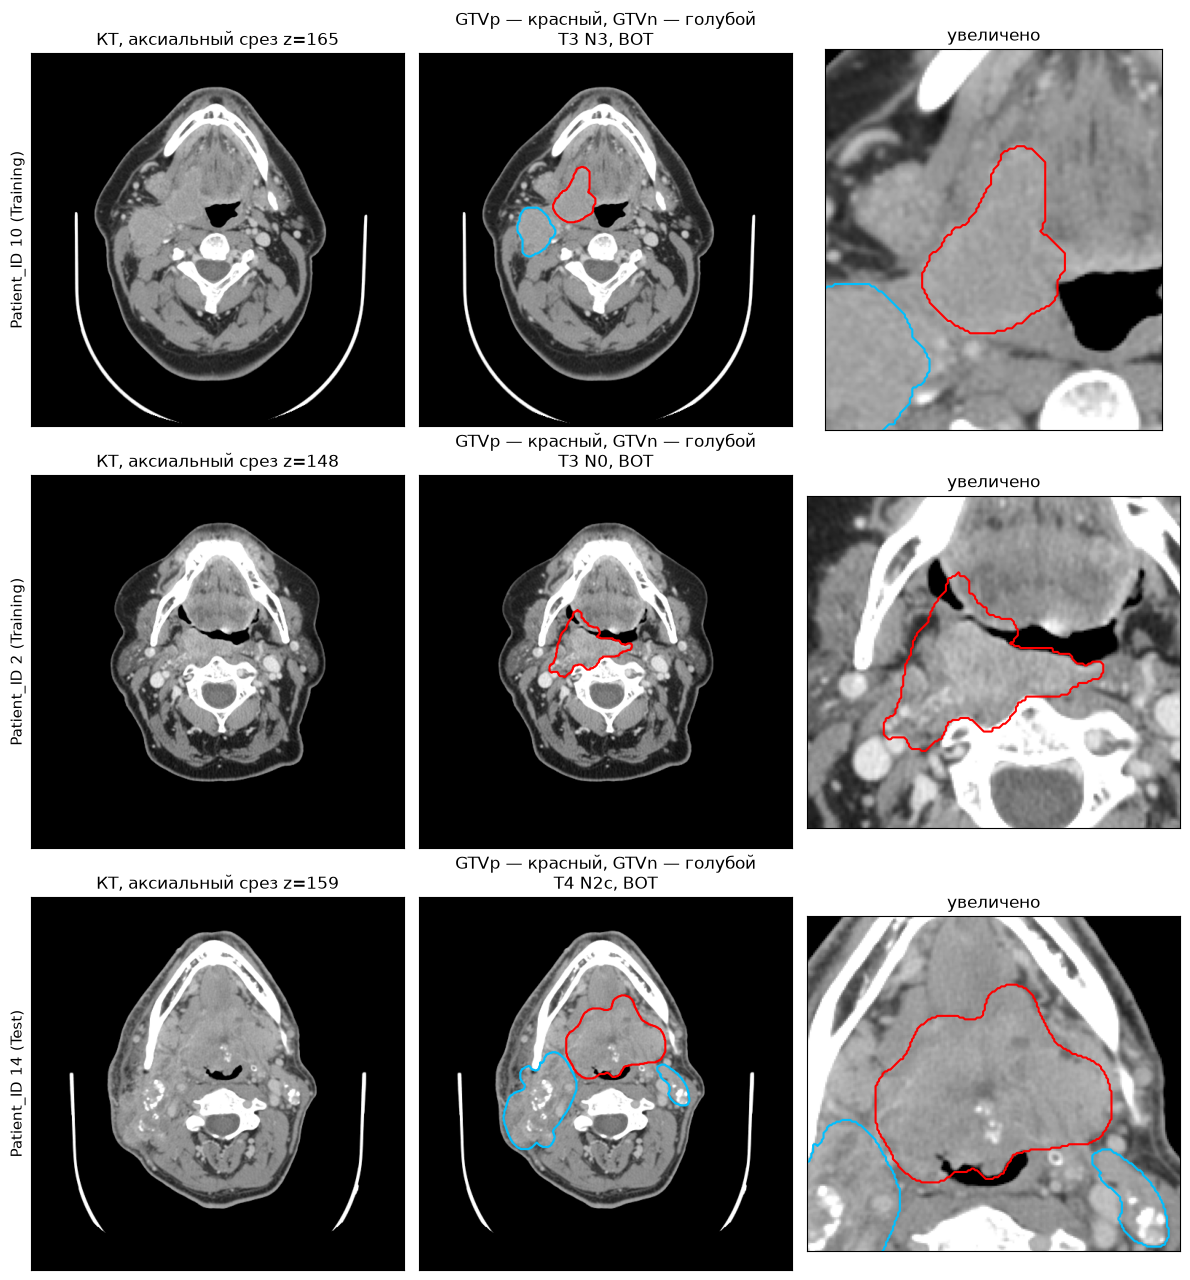

In [3]:
PART = {"Training": "обучающая часть", "Test": "тестовая часть"}
SUBSITE = {"BOT": "корень языка", "Tonsil": "миндалина", "GPS": "язычно-глоточная борозда",
           "Soft_palate": "мягкое нёбо", "Pharyngeal_wall": "стенка глотки", "Other": "другая"}


def load(row, name):
    path = case_dir(row) / f"{name}.nii.gz"
    return sitk.GetArrayFromImage(sitk.ReadImage(path)) if path.is_file() else None


def show_patient(row, axes, margin=40):
    ct = np.clip(load(row, "CT"), -160, 240)  # окно мягких тканей: L=40, W=400 HU
    gtvp = load(row, "GTVp") > 0
    gtvn = load(row, "GTVn")
    gtvn = gtvn > 0 if gtvn is not None else np.zeros_like(gtvp)

    z = int(np.argmax(gtvp.sum(axis=(1, 2))))  # срез с наибольшей площадью опухоли
    ys, xs = np.where(gtvp[z])
    for ax in axes:
        ax.imshow(ct[z], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[1:]:
        ax.contour(gtvp[z], levels=[0.5], colors="red")
        if gtvn[z].any():
            ax.contour(gtvn[z], levels=[0.5], colors="deepskyblue")
    axes[2].set_xlim(xs.min() - margin, xs.max() + margin)
    axes[2].set_ylim(ys.max() + margin, ys.min() - margin)

    axes[0].set_ylabel(f"пациент {row.Patient_ID}, {PART[row.Fold]}", fontsize=11)
    axes[0].set_title(f"КТ, аксиальный срез z={z}")
    axes[1].set_title(f"опухоль — красный, лимфоузлы — голубой\nT{row.T_category} N{row.N_category}, {SUBSITE[row.Tumor_subsite]}")
    axes[2].set_title("увеличено")


demo = clinical.set_index("Patient_ID").loc[[10, 2, 14]].reset_index()
fig, axes = plt.subplots(len(demo), 3, figsize=(12, 4.3 * len(demo)))
for row, ax_row in zip(demo.itertuples(), axes):
    show_patient(row, ax_row)
fig.tight_layout()
fig.savefig("text/fig/patients.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Извлечение радиомических признаков

In [4]:
settings = {
    "binWidth": 25,                      # по умолчанию
    "resampledPixelSpacing": [1, 1, 1],  # изотропный воксель 1 мм (толщина среза в наборе 0.4–5 мм)
    "interpolator": sitk.sitkBSpline,
    "preCrop": True,                     # обрезка вокруг маски перед ресэмплингом (ускорение)
}
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
print(extractor.settings)
print(list(extractor.enabledFeatures))

{'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': [1, 1, 1], 'interpolator': 23, 'preCrop': True, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'binWidth': 25}
['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm', 'shape']


In [5]:
def extract(ct, mask, prefix):
    result = extractor.execute(ct, mask)
    return {f"{prefix}_{k.removeprefix('original_')}": float(np.real(v))
            for k, v in result.items() if k.startswith("original_")}


def extract_patient(row):
    d = case_dir(row)
    if not (d / "GTVp.nii.gz").is_file():
        raise FileNotFoundError("нет маски первичной опухоли GTVp")
    ct = sitk.ReadImage(d / "CT.nii.gz")
    features = extract(ct, sitk.ReadImage(d / "GTVp.nii.gz"), "GTVp")

    if (d / "GTVn.nii.gz").is_file():
        gtvn = sitk.ReadImage(d / "GTVn.nii.gz")
        features["GTVn_n_nodes"] = len(np.unique(sitk.GetArrayViewFromImage(gtvn))) - 1
        features.update(extract(ct, sitk.Cast(gtvn > 0, sitk.sitkUInt8), "GTVn"))
    else:
        features["GTVn_n_nodes"] = 0
    return features


records, skipped = [], []
for row in tqdm(clinical.itertuples(), total=len(clinical), mininterval=30):
    try:
        records.append({"Patient_ID": row.Patient_ID, **extract_patient(row)})
    except Exception as e:
        skipped.append({"Patient_ID": row.Patient_ID, "Fold": row.Fold, "reason": str(e)})

features = pd.DataFrame(records)
skipped = pd.DataFrame(skipped)

  0%|          | 0/315 [00:00<?, ?it/s]

  2%|▏         | 6/315 [00:32<28:01,  5.44s/it]

  2%|▏         | 6/315 [00:50<28:01,  5.44s/it]

  4%|▍         | 13/315 [01:05<25:05,  4.98s/it]

  4%|▍         | 13/315 [01:20<25:05,  4.98s/it]

...

 97%|█████████▋| 307/315 [34:40<00:46,  5.84s/it]

 97%|█████████▋| 307/315 [34:55<00:46,  5.84s/it]

 99%|█████████▉| 312/315 [35:16<00:18,  6.26s/it]

 99%|█████████▉| 312/315 [35:35<00:18,  6.26s/it]

100%|██████████| 315/315 [35:35<00:00,  6.78s/it]

In [6]:
print(f"Признаки извлечены: {len(features)} из {len(clinical)} пациентов")
print(f"Пропущено: {len(skipped)}")
print(skipped.to_string(index=False))

Признаки извлечены: 298 из 315 пациентов
Пропущено: 17
 Patient_ID     Fold                           reason
          3 Training нет маски первичной опухоли GTVp
         17 Training нет маски первичной опухоли GTVp
         36 Training нет маски первичной опухоли GTVp
         76 Training нет маски первичной опухоли GTVp
         92 Training нет маски первичной опухоли GTVp
        112 Training нет маски первичной опухоли GTVp
        126 Training нет маски первичной опухоли GTVp
        127 Training нет маски первичной опухоли GTVp
        130 Training нет маски первичной опухоли GTVp
        164 Training нет маски первичной опухоли GTVp
        211     Test нет маски первичной опухоли GTVp
        221     Test нет маски первичной опухоли GTVp
        239     Test нет маски первичной опухоли GTVp
        242     Test нет маски первичной опухоли GTVp
        262     Test нет маски первичной опухоли GTVp
        271     Test нет маски первичной опухоли GTVp
        299     Test нет ма

In [7]:
gtvp_cols = [c for c in features if c.startswith("GTVp_")]
gtvn_cols = [c for c in features if c.startswith("GTVn_") and c != "GTVn_n_nodes"]
print(f"Признаков GTVp: {len(gtvp_cols)}, GTVn: {len(gtvn_cols)} + GTVn_n_nodes")
print(pd.Series([c.split("_")[1] for c in gtvp_cols]).value_counts().to_string())
print(f"\nNaN в признаках GTVp: {features[gtvp_cols].isna().sum().sum()}")
print(f"Пациентов без GTVn (признаки GTVn = NaN): {features[gtvn_cols[0]].isna().sum()}")
print("\nЧисло лимфоузлов GTVn_n_nodes:", features.GTVn_n_nodes.value_counts().sort_index().to_dict())

Признаков GTVp: 107, GTVn: 107 + GTVn_n_nodes
glcm          24
firstorder    18
glrlm         16
glszm         16
shape         14
gldm          14
ngtdm          5

NaN в признаках GTVp: 0
Пациентов без GTVn (признаки GTVn = NaN): 45

Число лимфоузлов GTVn_n_nodes: {0: 45, 1: 95, 2: 80, 3: 29, 4: 14, 5: 12, 6: 2, 7: 9, 8: 3, 10: 3, 12: 2, 13: 1, 14: 1, 16: 2}


            GTVp_firstorder_Median  GTVp_firstorder_Mean  \
Patient_ID                                                 
219                           65.0                -118.6   
257                          223.0                 349.7   
289                         -623.5                -472.2   

            GTVp_firstorder_10Percentile  
Patient_ID                                
219                               -960.0  
257                                 14.0  
289                               -975.0  


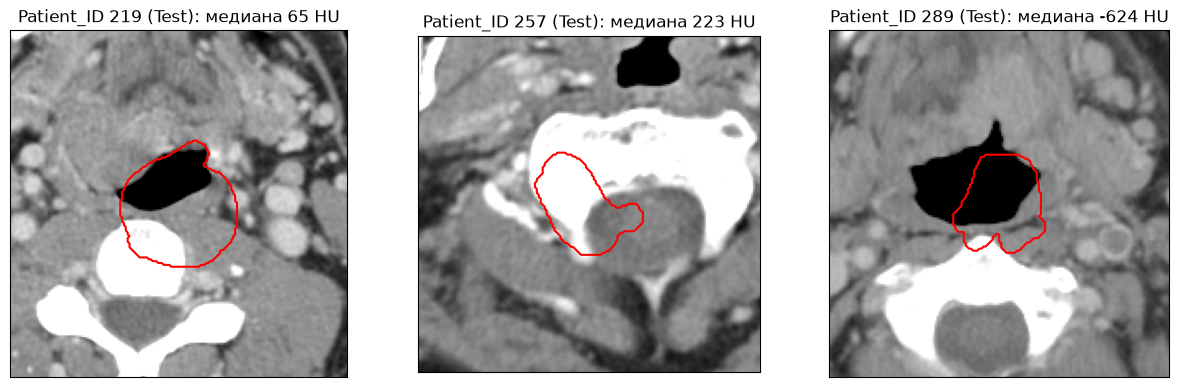

In [8]:
# контроль качества: нетипичная плотность внутри GTVp
hu = features.set_index("Patient_ID")[["GTVp_firstorder_Median", "GTVp_firstorder_Mean", "GTVp_firstorder_10Percentile"]]
outliers = hu[~hu.iloc[:, :2].apply(lambda s: s.between(-100, 200)).all(axis=1)]
print(outliers.round(1))

fig, axes = plt.subplots(1, len(outliers), figsize=(5 * len(outliers), 4.5), squeeze=False)
for ax, pid in zip(axes[0], outliers.index):
    row = pd.Series({"Patient_ID": pid, **clinical.set_index("Patient_ID").loc[pid]})
    ct, gtvp = np.clip(load(row, "CT"), -160, 240), load(row, "GTVp") > 0
    z = int(np.argmax(gtvp.sum(axis=(1, 2))))
    ys, xs = np.where(gtvp[z])
    ax.imshow(ct[z], cmap="gray")
    ax.contour(gtvp[z], levels=[0.5], colors="red")
    ax.set_xlim(xs.min() - 60, xs.max() + 60); ax.set_ylim(ys.max() + 60, ys.min() - 60)
    ax.set_title(f"пациент {pid}, {PART[row.Fold]}: медиана {outliers.loc[pid].iloc[0]:.0f} HU")
    ax.set_xticks([]); ax.set_yticks([])
fig.savefig("text/fig/qc.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Сводная таблица

In [11]:
dataset = clinical.drop(columns=["has_CT", "has_GTVp", "has_GTVn"]).merge(features, on="Patient_ID", validate="one_to_one")
dataset.to_csv("dataset.csv", index=False)

assert dataset.Patient_ID.is_unique and len(dataset) == len(features)
print(f"dataset.csv: {dataset.shape[0]} пациентов x {dataset.shape[1]} столбцов")
print(f"= Patient_ID + Fold + {clinical.shape[1] - 5} клинических + {len(gtvp_cols)} GTVp "
      f"+ {len(gtvn_cols)} GTVn + GTVn_n_nodes")
print(dataset.Fold.value_counts().to_dict())
dataset.head()

dataset.csv: 298 пациентов x 235 столбцов
= Patient_ID + Fold + 18 клинических + 107 GTVp + 107 GTVn + GTVn_n_nodes
{'Test': 158, 'Training': 140}


,Patient_ID,Fold,Local_tumor_recurrence,Gender,Age_at_diagnosis,Race,Tumor_side,Tumor_subsite,T_category,N_category,...,GTVn_glszm_SmallAreaHighGrayLevelEmphasis,GTVn_glszm_SmallAreaLowGrayLevelEmphasis,GTVn_glszm_ZoneEntropy,GTVn_glszm_ZonePercentage,GTVn_glszm_ZoneVariance,GTVn_ngtdm_Busyness,GTVn_ngtdm_Coarseness,GTVn_ngtdm_Complexity,GTVn_ngtdm_Contrast,GTVn_ngtdm_Strength
0,1,Training,0.0,Male,58,White,L,Tonsil,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Training,0.0,Female,78,White,R,BOT,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,Training,0.0,Female,56,White,R,BOT,2,2b,...,18.432932,0.045767,4.830265,0.021908,217207.210534,30.280940,0.000484,17.762981,0.013203,0.017681
3,5,Training,0.0,Female,60,White,L,Tonsil,2,2b,...,39.780025,0.014677,5.303423,0.032969,98241.254699,8.262735,0.000624,46.701054,0.011287,0.084864
4,6,Training,0.0,Male,66,White,R,BOT,1,1,...,23.701809,0.036914,5.005695,0.036318,56415.240284,5.626292,0.001414,27.871102,0.011375,0.099653
